# Práctica 6: Análisis de Componentes Principales (PCA)
### Autor: Eduardo Sánchez Sarsa (901813)
### Versión 1.0
### Fecha: 15-3-2024

---

En este template, hay alguna función que requiere `scikit-learn>=1.3`. La siguiente celda <br>
comprueba la versión de `scikit-learn` que está instalada en tu entorno. Si no está esta versión <br>
y se está trabajando en `Google Colab`, la siguiente celda instala la versión necesaria. Si se está <br>
trabajando en local (p. ej. con `conda`), por favor, instala versión necesaria manualmente.

In [1]:
from packaging import version

import sklearn

# # en Google Colab?
# try:
#     import google.colab  # type:ignore

#     IN_COLAB = True
# except ImportError:
IN_COLAB = False

# sklearn >= 1.3?
sklearn_version = sklearn.__version__
if version.parse(sklearn_version) < version.parse("1.3"):
    if IN_COLAB:
        print("Instalando scikit-learn version >= 1.3. ...")
        %pip uninstall scikit-learn -y
        %pip install -U scikit-learn
    else:
        msg = "Por favor, actualiza manualmente la versión de scikit-learn a >= 1.3 en tu entorno virtual."
        raise ImportError(msg)
else:
    print(f"La versión de scikit-learn ({sklearn_version}) es suficiente (>= 1.3).")

La versión de scikit-learn (1.8.0) es suficiente (>= 1.3).


In [2]:
from time import perf_counter

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)
from sklearn.model_selection import (
    ValidationCurveDisplay,  # type: ignore
    train_test_split,
)

# descomenta %matplotlib qt si prefieres plots interactivos
%matplotlib inline
# %matplotlib qt

## 0. Carga de datos

In [3]:
# El dataset puede encontrarse en:
# https://github.com/zalandoresearch/fashion-mnist
# Para mayor facilidad, vamos a cargarlo directamente de:
# https://www.openml.org/search?type=data&sort=runs&id=40996&status=active
fashion_mnist = fetch_openml("Fashion-MNIST", parser="pandas")

# numpy ndarrays con las features y el target
X = fashion_mnist.data.values / 255  # (70000, 784=28x28) en [0, 1]
y = fashion_mnist.target.values.astype(int)  # (70000,) en [0, 9]

# el dataset está estructurado de tal forma que las primeras 60.000 instancias
# (imágenes) son de entrenamiento y las últimas 10.000 de test:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=int(1e4), shuffle=False
)

# En Fashion-MNIST, cada valor númerico se corresponde con una prenda. Usaremos el
# siguiente diccionario para el mapeo número -> prenda:
target_names = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot",
}

# o si las preferimos recuperar en español:
target_names_esp = {
    0: "Camiseta",
    1: "Pantalón",
    2: "Suéter",
    3: "Vestido",
    4: "Abrigo",
    5: "Sandalia",
    6: "Camisa",
    7: "Zapatilla",
    8: "Bolso",
    9: "Bota",
}

Vamos a explorar brevemente el dataset para hacernos una idea de su contenido:

In [45]:
print("¿Cuántas imágenes de cada prenda hay en el dataset de entrenamiento?:")
print("¿Está balanceado?\N{THINKING FACE}:\n")
unique, counts = np.unique(y_train, return_counts=True)
print(f"{'Prenda':20} #Imágenes")
print("-" * 30)
for u, c in zip(unique, counts):
    print(f"{target_names_esp[u]:25}{c}")

¿Cuántas imágenes de cada prenda hay en el dataset de entrenamiento?:
¿Está balanceado?🤔:

Prenda               #Imágenes
------------------------------
Camiseta                 6000
Pantalón                 6000
Suéter                   6000
Vestido                  6000
Abrigo                   6000
Sandalia                 6000
Camisa                   6000
Zapatilla                6000
Bolso                    6000
Bota                     6000


Vamos a definir una función que nos permita visualizar una muestra de imágenes del dataset:

In [4]:
def visualize_subset_in_grid(
    images,
    labels,
    predicted_labels=None,
    subset=25,
    esp=True,
    random=True,
    ncols=None,
    fig=None,
    ax=None,
):
    """Visualiza un subset de imágenes en una cuadrícula.

    Args:
        images: (n, 784) array con n imágenes 28x28 de Fasion-MNIST.
        labels: (n,) array con las etiquetas (numéricas) de las n imágenes.
        predicted_labels: (n,) array con las etiquetas predichas por un modelo.
        subset: Si es un integer, número de imágenes a visualizar, si es una secuencia
            de enteros, visualiza las imágenes con esos índices.
        esp: Si True, las etiquetas se mostrarán en español.
        random: Si True y subset es un entero, las imágenes se seleccionarán
            aleatoriamente.
        ncols: Número de columnas de la cuadrícula. Si es None, se usará una grid
            cuadrada.
        fig: Figura de matplotlib en la que visualizar las imágenes. Si es None, se
            creará una nueva figura.
        ax: Array de ejes de matplotlib en los que visualizar las imágenes. Si es None,
            se crearán nuevos ejes.
    """
    assert images.shape[1] == 784, "Las imágenes deben ser de 28x28 píxeles."
    assert len(images) == len(labels), "#imagenes debe coincidir con el de labels."

    if isinstance(subset, int):
        if random:
            subset = np.random.choice(images.shape[0], subset, replace=False)
        else:
            subset = np.arange(subset)

    n = len(subset)
    if ncols is None:
        ncols = int(np.ceil(np.sqrt(n)))
    nrows = int(np.ceil(n / ncols))

    def get_title_and_color(i):
        if predicted_labels is None:
            if isinstance(labels[i], str):
                return labels[i], {"color": "black"}
            else:
                return names[labels[i]], {"color": "black"}

        is_correct = labels[i] == predicted_labels[i]
        symbol = (
            f"\N{HEAVY CHECK MARK}" if is_correct else f"\N{HEAVY MULTIPLICATION X}"
        )
        title = f"{names[labels[i]]}/{names[predicted_labels[i]]} {symbol}"
        color = "green" if labels[i] == predicted_labels[i] else "red"
        return title, {"color": color}

    if fig is None or ax is None:
        fig, ax = plt.subplots(nrows, ncols, figsize=(ncols * 2, nrows * 2))
    names = target_names_esp if esp else target_names
    for i, axi in zip(subset, ax.ravel()):
        axi.imshow(images[i].reshape(28, 28), cmap="gray")
        axi.set_title(*get_title_and_color(i))
        axi.axis("off")
    fig.tight_layout()

Por cada ejecución de la siguiente celda se visualizan distintas muestras de Fashion-MNIST.

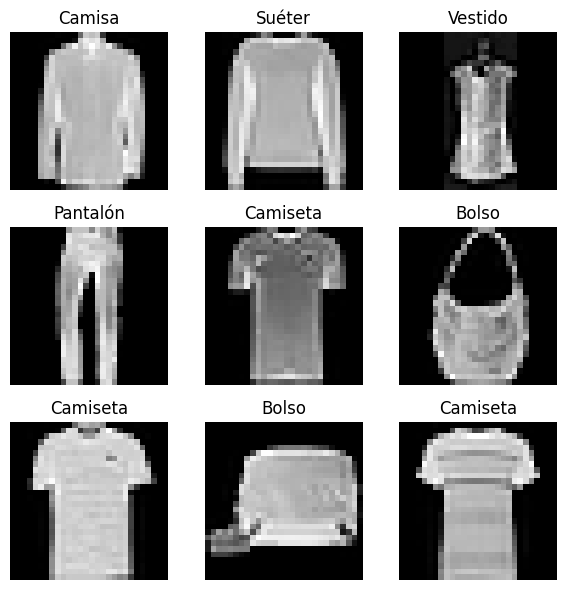

In [8]:
# visualizar un subset de las imágenes
visualize_subset_in_grid(X_train, y_train, subset=9, random=True)

## 1. Preparación de nuestro clasificador (Práctica 5)

Antes de aplicar **PCA** a Fashion-MNIST, a modo de referencia, vamos a crear un <br/>
clasificador Bayesiano "base", tal y como se hizo en la Práctica 5, pero <br/>
particularizándolo a las estadísticas de **Fashion-MNIST**.

Este modelo, entrenado con los datos originales, nos servirá para comparar y comprobar <br/>
la eficacia de **PCA** en la reducción de dimensionalidad.

Primero definimos algunas funciones auxiliares que nos servirán para evaluar los clasificadores...

In [5]:
def evaluar_clasificador(
    clf,
    X_train,
    y_train,
    X_test,
    y_test,
    do_report=True,
    do_cm=True,
    display_labels=None,
):
    """Evaluación de un clasificador.

    Args:
        clf: Clasificador a evaluar.
        X_train, y_train: Conjunto de entrenamiento.
        X_test, y_test: Conjunto de test.
        do_report: Si True, se muestra el report de clasificación.
        do_cm: Si True, se muestra la matriz de confusión.
        display_labels: Nombres de las clases para mostrar en la matriz de confusión.

    Returns:
        Diccionario con los resultados de la evaluación:
            - Tiempo de entrenamiento.
            - Accuracy en el conjunto de entrenamiento.
            - Accuracy en el conjunto de test.
    """
    # tiempo de entrenamiento
    t0 = perf_counter()
    clf.fit(X_train, y_train)
    t1 = perf_counter()
    y_pred = clf.predict(X_test)
    y_pred_train = clf.predict(X_train)
    if do_cm:
        # matriz de confusión
        cm_display = ConfusionMatrixDisplay.from_predictions(
            y_test, y_pred, display_labels=display_labels, xticks_rotation=60.0
        )
        cm_display.ax_.set_title(repr(clf))
    if do_report:
        # report de clasificación
        print(
            classification_report(y_test, y_pred, target_names=display_labels, digits=2)
        )
    # recopilamos algunos resultados para reportarlos en otra función.
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred)
    results = {
        "Tiempo train (sec.)": t1 - t0,
        "Acc. (train)": acc_train,
        "Acc. (test)": acc_test,
    }
    return results


def evaluar_clasificadores(clfs, X_train, y_train, X_test, y_test):
    """Evaluación de varios clasificadores."""
    assert iter(clfs), "clfs debe ser un iterable de clasificadores."
    display_labels = list(target_names_esp.values())
    all_results = {}
    name_mlen = 0
    for clf in clfs:
        name = repr(clf)
        print(f"\n{name}:\n{'-' * (len(name) + 1)}")
        all_results[name] = evaluar_clasificador(
            clf, X_train, y_train, X_test, y_test, display_labels=display_labels
        )
        name_mlen = max(name_mlen, len(name))

    # reporte global de precisión y tiempo de entrenamiento
    headers = [f"{'Modelo':<{name_mlen}}"] + [
        f"{k:>{len(k)}}" for k in all_results[name].keys()
    ]
    print("\n" + "  ".join(headers))
    print("-" * len("  ".join(headers)))
    for name, results in all_results.items():
        row = [f"{name:<{name_mlen}}"] + [
            f"{v:>{len(k)}.2f}" for k, v in results.items()
        ]
        print("  ".join(row))
    print()

La siguiente celda es **opcional** ejecutarla. Esta celda, evalúa uno de los clasificadores propuestos <br> 
en la P5, pero sobre los datos de entrenamiento de Fashion-MNIST. 

En esta Práctica 6, **ya aportamos un clasificador por defecto**. Por tanto, no es necesario <br> 
ejecutar esta celda. Solamente la dejamos por reproducibilidad y mayor claridad. <br>

Empleamos LDA por ser más rápido y proporcionar resultados mejores a Bayes ingenuo y QDA.

Evaluando LDA...


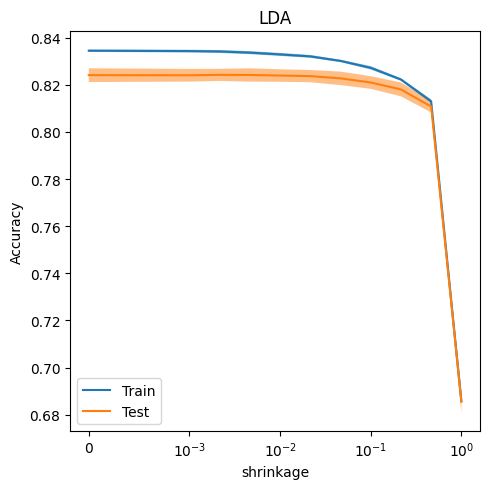

In [10]:
# Configuración para la validación cruzada de cada clasificador.
clasificadores = {
    "LDA": {
        "clf": LinearDiscriminantAnalysis(solver="lsqr"),
        "param_name": "shrinkage",  # (1-shrinkage)*S + (shrinkage*Tr(S)/n)*I_n
        "param_range": np.r_[0.0, np.logspace(-3, 0, 10)],
    }
}

fig, ax = plt.subplots(len(clasificadores), 1, figsize=(5, 5 * len(clasificadores)))
for i, (name, config) in enumerate(clasificadores.items()):
    print(f"Evaluando {name}...")
    ValidationCurveDisplay.from_estimator(
        config["clf"],
        X_train,
        y_train,
        param_name=config["param_name"],
        param_range=config["param_range"],
        scoring="accuracy",
        cv=int(
            len(X_train) / (0.25 * len(X_train))
        ),  # 25% de las imágenes en cada fold
        n_jobs=4,  # usar todos los cores
        ax=ax,
    )
    ax.set_title(name)
    ax.set_xscale("symlog", linthresh=1e-3)
fig.tight_layout()

Por completitud, añadimos los resultados de test y training para LDA:


LinearDiscriminantAnalysis(shrinkage=0.001, solver='lsqr'):
-----------------------------------------------------------
              precision    recall  f1-score   support

    Camiseta       0.81      0.78      0.79      1000
    Pantalón       1.00      0.93      0.96      1000
      Suéter       0.70      0.68      0.69      1000
     Vestido       0.80      0.84      0.82      1000
      Abrigo       0.70      0.74      0.72      1000
    Sandalia       0.89      0.89      0.89      1000
      Camisa       0.54      0.56      0.55      1000
   Zapatilla       0.88      0.89      0.89      1000
       Bolso       0.93      0.92      0.93      1000
        Bota       0.91      0.91      0.91      1000

    accuracy                           0.81     10000
   macro avg       0.82      0.81      0.82     10000
weighted avg       0.82      0.81      0.82     10000


Modelo                                                      Tiempo train (sec.)  Acc. (train)  Acc. (test)
------------

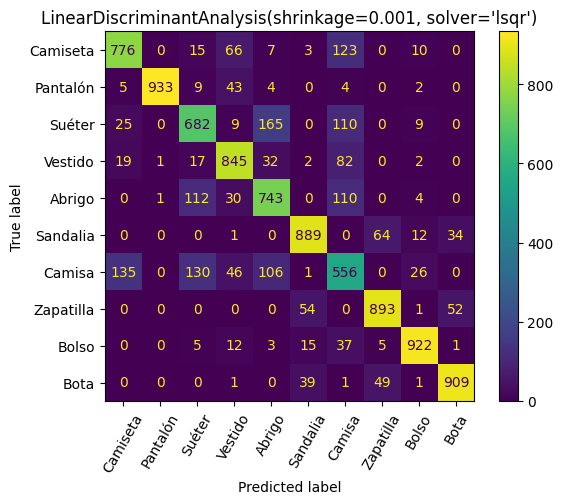

In [13]:
lda = LinearDiscriminantAnalysis(shrinkage=0.001, solver="lsqr")

evaluar_clasificadores([lda], X_train, y_train, X_test, y_test)

La siguiente celda instancia el *clasificador que emplearemos* en el resto de la práctica:

In [8]:
clf = LinearDiscriminantAnalysis(shrinkage=0.001, solver="lsqr")

## 2. Análisis de Componentes Principales (PCA)

Para entender los resultados posteriores, en primer lugar visualiza las (6, por ejemplo) <br> 
componentes **más** y **menos principales**.

Para visualizarlas, te recomendamos emplear la función `visualize_subset_in_grid` <br>
definida anteriormente.

Una vez las visualices, explica por qué crees que dichas componentes principales son así.

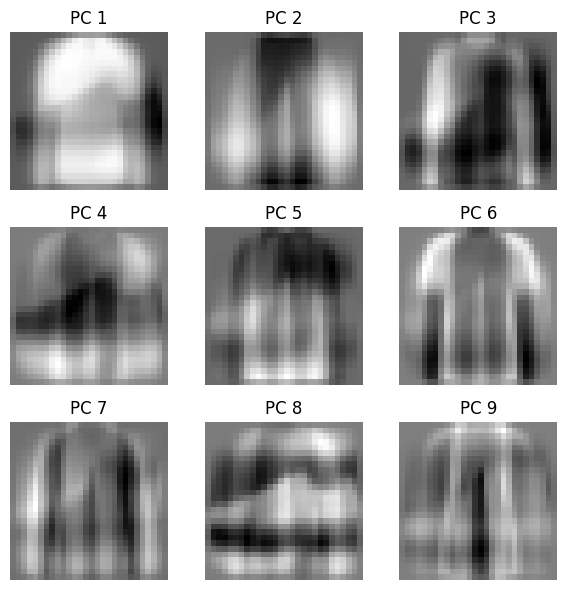

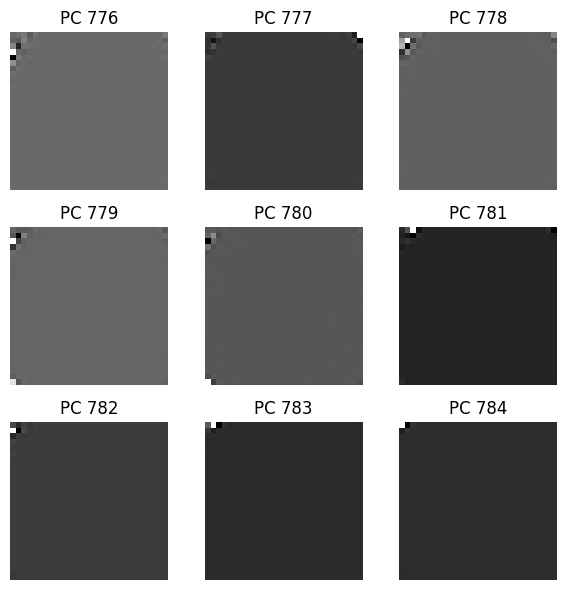

In [23]:
# TODO: tu código
pca = PCA()
pca.fit(X_train)

labels = np.array([f"PC {i+1}" for i in range(pca.components_.shape[0])], dtype=object)

# 6 componentes más principales
visualize_subset_in_grid(
    pca.components_,
    labels,
    subset=np.arange(9),
    random=False
)

# 6 componentes menos principales
visualize_subset_in_grid(
    pca.components_,
    labels,
    subset=np.arange(pca.components_.shape[0] - 9, pca.components_.shape[0]),
    random=False
)


## Explicación.

Estas componentes son significativas, porque ayudan a indentificar distintos tipos de prendas, digamos que cada componente captura la variabilidad de determinados tipos de prenda, por ejemplo en el PC 1, vemos claramente que captura la variabilidad de las camisetas y las zapatillas, el PC 2, pantalones y parece que abrigos...

### 2.1 a) ¿Con cuántas de las 784 componentes te puedes quedar sin alterar los resultados de la clasificación?

Para contestar este apartado te recomendamos emplear la función `evaluar_clasificador` <br>
definida anteriormente.

Explica los resultados obtenidos.

In [34]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# 1. Crear un pipeline que primero aplique PCA y luego tu clasificador
# Nota: reemplaza 'clf' por la variable real de tu clasificador (ej. RandomForestClassifier(), SVC(), etc.)
pipeline = Pipeline([
    ('pca', PCA()),
    ('clf', clf) 
])

# 2. El param_grid ahora debe indicar a qué paso del pipeline pertenece el parámetro (usando pca__)
param_grid = {
    "pca__n_components": np.linspace(10, 784, 400, dtype=int)
}

grid_pca = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=4,               # 4 folds equivale a bloques del 25% de los datos
    scoring="accuracy",
    n_jobs=4,           # Usar 4 cores
    # return_train_score=True,
)

# Entrenar el GridSearch
grid_pca.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='lsqr'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'pca__n_components': array([ 10, ...80, 782, 784])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : 

Accuracy de referencia (784 componentes): 0.8240
El menor número de componentes que iguala/supera a 784 es: 652


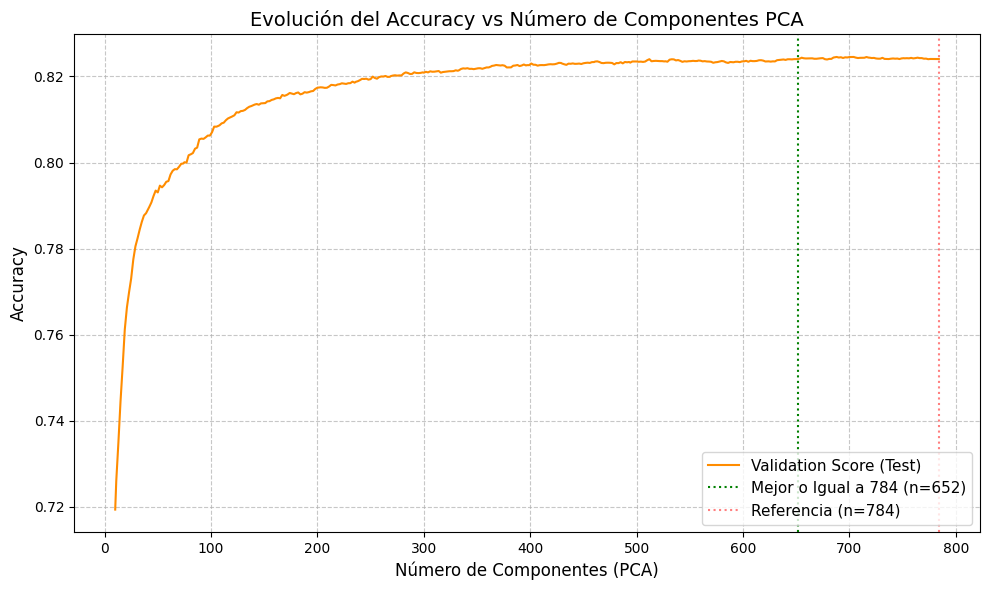

In [36]:
resultados = pd.DataFrame(grid_pca.cv_results_)

# Quitamos 'mean_train_score' de aquí
columnas_interes = ['param_pca__n_components', 'mean_test_score']
resultados = resultados[columnas_interes].sort_values(by='param_pca__n_components')

acc_784 = resultados[resultados['param_pca__n_components'] == 784]['mean_test_score'].values[0]

mejores_candidatos = resultados[resultados['mean_test_score'] >= acc_784]
mejor_n_componentes = mejores_candidatos['param_pca__n_components'].min()

print(f"Accuracy de referencia (784 componentes): {acc_784:.4f}")
print(f"El menor número de componentes que iguala/supera a 784 es: {mejor_n_componentes}")

plt.figure(figsize=(10, 6))

x = resultados['param_pca__n_components']
y_test = resultados['mean_test_score']

# Solo graficamos el test score
plt.plot(x, y_test, label='Validation Score (Test)', linestyle='-', color='darkorange')

plt.axvline(x=mejor_n_componentes, color='green', linestyle=':', 
            label=f'Mejor o Igual a 784 (n={mejor_n_componentes})')
plt.axvline(x=784, color='red', linestyle=':', alpha=0.5, 
            label='Referencia (n=784)')

plt.title('Evolución del Accuracy vs Número de Componentes PCA', fontsize=14)
plt.xlabel('Número de Componentes (PCA)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

## Para obtener el mismo accuracy solo podemos eliminar 132 dimensiones
Como vemos en la gráfica, en la curva, el mínimo número mejor o igual a el accuracy con 784 dimensiones es el 652, aunque vemos también en la que realmente, seguiríamos en el 0.82 de accuracy bajando hasta las casi 270 dimensiones, manteniendo un $82$% de accuracy.

### 2.1 b) Si reduces las dimensiones de los datos para mantener el 99% de la variabilidad, ¿qué tan buenos son los resultados de la clasificación?

Comenta los resultados, compara con los obtenidos sin aplicar PCA (ya aportados en este template) <br>
y con los que has obtenido en la pregunta anterior.

              precision    recall  f1-score   support

    Camiseta       0.81      0.78      0.79      1000
    Pantalón       1.00      0.93      0.96      1000
      Suéter       0.71      0.69      0.70      1000
     Vestido       0.81      0.84      0.83      1000
      Abrigo       0.70      0.75      0.73      1000
    Sandalia       0.89      0.89      0.89      1000
      Camisa       0.55      0.56      0.55      1000
   Zapatilla       0.89      0.89      0.89      1000
       Bolso       0.93      0.93      0.93      1000
        Bota       0.91      0.92      0.91      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000



{'Tiempo train (sec.)': 3.4876702999999907,
 'Acc. (train)': 0.8283,
 'Acc. (test)': 0.8164}

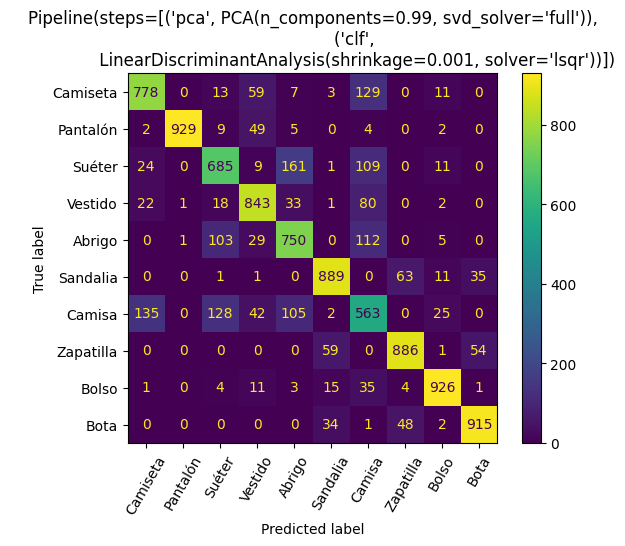

In [46]:
# TODO: tu código
# Entrena el pipeline antes de evaluar
pipeline = Pipeline([( 'pca', PCA(n_components=0.99, svd_solver="full") ), ('clf', clf)])
pipeline.fit(X_train, y_train)

evaluar_clasificador(pipeline, X_train, y_train, X_test, y_test, display_labels=list(target_names_esp.values()))

## Conclusiones:
Los resultados que vemos son igual de buenos que el que con el 100% de la variabilidad, al menos si contemplamos únicamente el *accuracy*, es por ello que el modelo tampoco sufre ningún cambio drástico al dejar el 99% de variabilidad. 

### 2.1 c) Reconstruye alguna imagen del dataset de entrenamiento.

Cualitativamente, podemos comprobar la información retenida por las componentes, <br>
reconstruyendo las imágenes desde el espacio de dimensionalidad reducida, y de forma <br>
cuantitativa, mediante la métrica [***PSNR***](https://en.wikipedia.org/wiki/Peak_signal-to-noise_ratio) (*Peak Signal-to-Noise Ratio*).

Puedes utilizar la función `calculate_psnr`, definida a continuación, para calcular el [PSNR](https://en.wikipedia.org/wiki/Peak_signal-to-noise_ratio) <br> 
de un conjunto de imágenes reconstruidas respecto a las originales. 

Para comparar visualmente las imágenes reconstruidas, te recomendamos completar la función <br> 
`show_reconstruction_vs_ncomponents`.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def calculate_psnr(imgs, reconstructed_imgs):
    """Peak Signal-to-Noise Ratio (PSNR) para batch de imágenes.

    Args:
        imgs: (n, d) array con n imágenes 28x28.
        reconstructed_imgs: (n, d) array con las imágenes reconstruidas.

    Returns:
        psnr: (n,) array con el PSNR de cada imagen reconstruida.
    """
    mse = np.mean((imgs - reconstructed_imgs) ** 2, axis=1)
    psnr = np.empty_like(mse)
    mask = mse == 0
    psnr[mask] = np.inf
    R2 = 1.0 if imgs.max() <= 1 + 1e-9 else 255**2  # rango de los píxeles
    psnr[~mask] = 10 * np.log10(R2 / mse[~mask])
    return psnr

def show_reconstruction_vs_ncomponents(X, n_components=None, idx=None):
    """Reconstruye y visualiza una imagen a partir de sus componentes principales."""
    
    if n_components is None:
        n_components = np.linspace(10, X.shape[1], 5).astype(int)
    if idx is None:
        idx = np.random.choice(len(X))

    # Obtenemos la imagen original manteniendo la forma (1, d) para que 
    # sea compatible con PCA y calculate_psnr
    img_original = X[idx:idx+1]

    # Preparamos la figura con tantos subplots como valores en n_components
    n_plots = len(n_components)
    fig, axes = plt.subplots(1, n_plots, figsize=(3 * n_plots, 4))
    
    # Asegurar que axes es iterable incluso si solo hay 1 componente
    axes = np.atleast_1d(axes)

    for ax, nc in zip(axes, n_components):
        # Instanciar y entrenar PCA con el número de componentes actual
        pca = PCA(n_components=nc)
        pca.fit(X)
        
        # Transformar (comprimir) y luego aplicar la transformada inversa (reconstruir)
        img_transformed = pca.transform(img_original)
        img_reconstructed = pca.inverse_transform(img_transformed)
        
        # Calcular el PSNR usando tu función
        psnr = calculate_psnr(img_original, img_reconstructed)[0]
        
        # Mostrar la imagen (redimensionando de 784 a 28x28)
        ax.imshow(img_reconstructed.reshape(28, 28), cmap='gray')
        ax.set_title(f"PCs: {nc}\nPSNR: {psnr:.2f} dB")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

Ejemplo de resultado (recuerda completar `show_reconstruction_vs_ncomponents`):

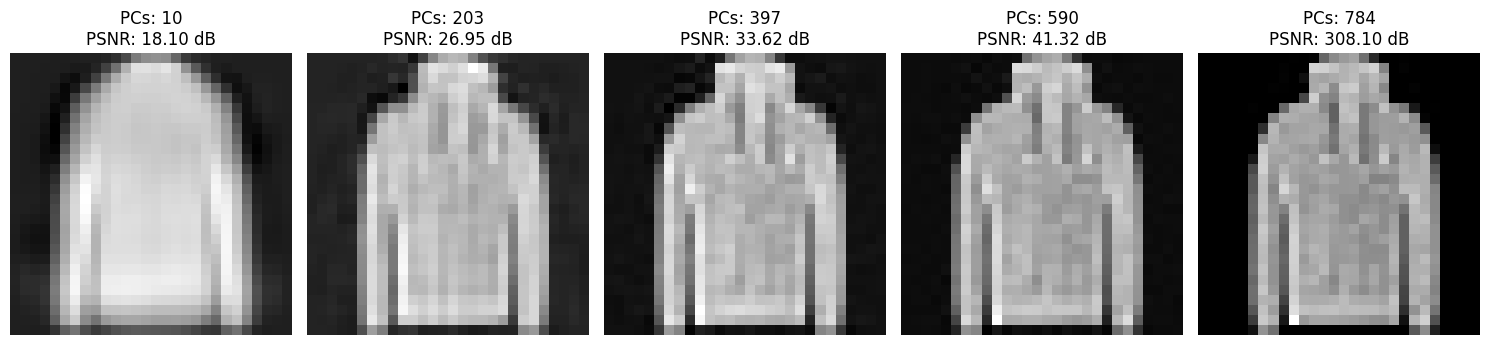

In [7]:
idx = None
n_components = np.linspace(10, X_train.shape[1], 5).astype(int)
show_reconstruction_vs_ncomponents(X_train, n_components, idx)

## Conclusión.

En las 5 imágenes, de menor a mayor número de componentes usados, podemos ver que con 10 componentes, la imagen nos sirve para definir el contorno de la prenda. Y al ir aumentando las componentes se va añadiendo un grado de detalle a la reconstrucción, hasta las 784, que es la imagen original. 

Esto se puede ver también en el aumento del PSNR, a mayor semejanza a la original, mayor es el PSNR, que indica un menor error.

### 2. Filtrado de ruido en imágenes.

En esta última parte, vamos a analizar la utilidad de PCA para filtrar ruido Gaussiano en imágenes.

In [8]:
def add_noise_to_images(X, noise_std):
    """Añade ruido Gaussiano (centrado en 0) de magnitud `noise_std` a las imágenes ."""
    return np.clip(X + noise_std * np.random.randn(*X.shape), 0, 1)

El siguiente widget visualiza de forma interactiva como afecta el ruido a las imágenes de <br>
Fashion-MNIST, para diferentes valores de `noise_std`:

In [ ]:
ncols = 3
subset = np.random.choice(len(X_train), 12, replace=False)
nrows = int(np.ceil(len(subset) / ncols))


@widgets.interact(noise_level=(0, 0.5, 0.01))
def display_images(noise_level=0.3):
    images = X_train[subset]
    images = add_noise_to_images(images, noise_level)
    fig, ax = plt.subplots(nrows, ncols, figsize=(ncols * 1.5, nrows * 1.5))
    visualize_subset_in_grid(
        images, y_train[subset], subset=len(subset), fig=fig, ax=ax, random=False
    )
    plt.show()

interactive(children=(FloatSlider(value=0.3, description='noise_level', max=0.5, step=0.01), Output()), _dom_c…

## EXPLICACIÓN:
Cuando no hay ruido vemos la prenda tal cual, en blanco y negro y sin ninguna modificación. "Nítido"

Al añadir un ruido de 0.10, empezamos a ver como los píxeles de la imagen empiezan a cambiar de forma aleatoria a lo largo de la imagen, pero siguen siendo reconocibles, las podemos seguir identificando, alguna con algo de dificultad.

Al subir el ruido a 0.30, ya vemos casos de prendas irreconocibles, como el suéter, o el vestido.
Estos valores de píxeles aleatorios ya se comen la imagen, hacinedo en muchos casos que sean irreconocibles.


La siguiente celda controla el ruido añadido al dateset mediante `noise_std`:

In [12]:
noise_std = 0.3
X_train_noisy = add_noise_to_images(X_train, noise_std=noise_std)
X_test_noisy = add_noise_to_images(X_test, noise_std=noise_std)

#### 2. a) Utiliza PCA para eliminar el ruido de las imágenes.

En la siguiente celda, visualizamos de forma interactiva el *PSNR* de **todas** las imágenes reconstruidas <br>
con PCA, en función del número de componentes principales indicadas con el slider `n_components`. 

También se visualiza el filtrado de ruido para una imagen de forma interactiva <br> 
(seleccionada con el slider `idx`).

In [15]:
pca_full = PCA()
pca_full.fit(X_train_noisy)
components_full = pca_full.components_  # (n_components, 784)
# reference PSNR values.
psnr_noisy = calculate_psnr(X_train, X_train_noisy)
min_noisy = np.min(psnr_noisy)
max_noisy = np.max(psnr_noisy)


@widgets.interact(n_components=(4, 784, 10), idx=(0, len(X_train_noisy), 1))
def show_reconstruction_vs_ncomponents(n_components=784, idx=0):
    """Visualización interactiva del filtrado de ruido con PCA."""
    # Monkey-patching para evitar calcular de nuevo los componentes principales.
    pca_full.components_ = components_full[:n_components]
    # imágenes filtradas con PCA y sus correspondientes PSNR.
    X_recon = pca_full.inverse_transform(pca_full.transform(X_train_noisy))

    psnr_pca = calculate_psnr(X_train, X_recon)  # (n,)
    binwidth = 0.1
    bins = np.arange(
        min(min_noisy, np.min(psnr_pca)),
        max(max_noisy, np.max(psnr_pca)) + binwidth,
        binwidth,
    )
    # visualización
    fig, ax = plt.subplots(2, 2, figsize=(5, 5))
    ax[0, 0].imshow(X_train[idx].reshape(28, 28), cmap="gray")
    ax[0, 0].set_title("Original")
    ax[0, 1].imshow(X_train_noisy[idx].reshape(28, 28), cmap="gray")
    ax[0, 1].set_title("Ruidosa")
    ax[1, 0].imshow(X_recon[idx].reshape(28, 28), cmap="gray")
    ax[1, 0].set_title("Filtrada")
    # psnr histograms
    ax[1, 1].hist(psnr_noisy, bins=bins, alpha=0.5, label="Ruidosa")
    ax[1, 1].hist(psnr_pca, bins=bins, alpha=0.5, label="Filtrada")
    ax[1, 1].set_xlabel("PSNR")
    ax[1, 1].legend()
    fig.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=784, description='n_components', max=784, min=4, step=10), IntSlider(val…

Modifica los niveles de ruido (`noise_std`) y utiliza el widget para explicar el comportamiento de <br>
PCA.

Para explicarlo, te recomendamos comparar los valores singulares, con y sin ruido (accesibles con el <br>
atributo [`singular_values_`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#:~:text=equal%20to%201.0.-,singular_values_,-ndarray%20of%20shape)) 
o visualizando, para las imágenes ruidosas, la curva con: <br> 
(eje y) error de reconstrucción o PSNR, (eje x) número de componentes empleados en la reconstrucción.

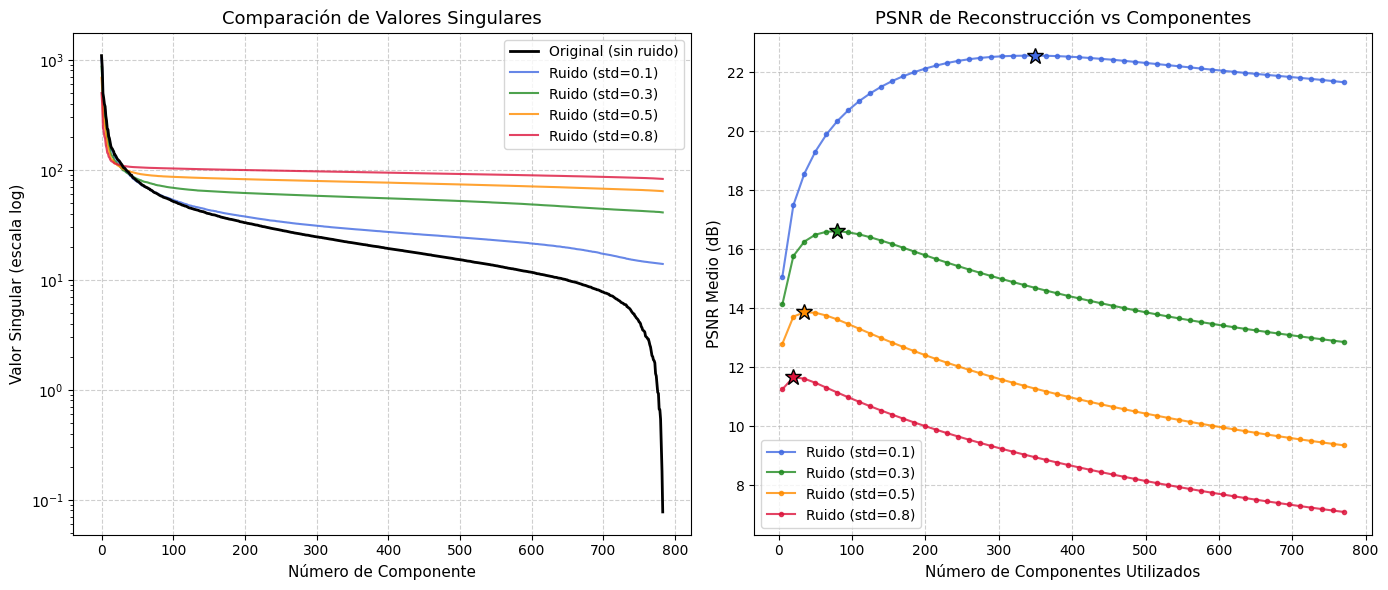

In [ ]:
niveles_ruido = [0.1, 0.3, 0.5, 0.8]

# Todo código relativo a la visualización de los resultados ha sido realizado por IA.

# PCA siN ruido
pca_clean = PCA()
pca_clean.fit(X_train)

n_components_range = np.arange(5, 784, 15)

# --- PREPARAMOS LA VISUALIZACIÓN ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].plot(pca_clean.singular_values_, label="Original (sin ruido)", color='black', linewidth=2, zorder=10)
colores = ['royalblue', 'forestgreen', 'darkorange', 'crimson', 'purple']

for i, noise_std in enumerate(niveles_ruido):
    color = colores[i % len(colores)]
    
    X_train_noisy = X_train + np.random.normal(0, noise_std, X_train.shape)
    X_train_noisy = np.clip(X_train_noisy, 0., 1.)
    
    pca_full = PCA()
    pca_full.fit(X_train_noisy)
    components_full = pca_full.components_
    
    
    axes[0].plot(pca_full.singular_values_, label=f"Ruido (std={noise_std})", color=color, alpha=0.8)
    
    # Calcular el PSNR
    psnr_means = []
    for nc in n_components_range:
        pca_full.components_ = components_full[:nc]
        X_recon_temp = pca_full.inverse_transform(pca_full.transform(X_train_noisy))
        psnr_temp = calculate_psnr(X_train, X_recon_temp)
        psnr_means.append(np.mean(psnr_temp))
    
    pca_full.components_ = components_full
    
    # Código Generado por IA.
    axes[1].plot(n_components_range, psnr_means, label=f"Ruido (std={noise_std})", color=color, marker='.', alpha=0.8)
    
    # Marcar el pico (mejor número de componentes) con una estrella
    mejor_idx = np.argmax(psnr_means)
    mejor_nc = n_components_range[mejor_idx]
    mejor_psnr = psnr_means[mejor_idx]


    # Código Generado por IA.
    axes[1].plot(mejor_nc, mejor_psnr, marker='*', markersize=12, color=color, markeredgecolor='black', zorder=10)

# Código generado por IA.
axes[0].set_yscale('log')
axes[0].set_title("Comparación de Valores Singulares", fontsize=13)
axes[0].set_xlabel("Número de Componente", fontsize=11)
axes[0].set_ylabel("Valor Singular (escala log)", fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

axes[1].set_title("PSNR de Reconstrucción vs Componentes", fontsize=13)
axes[1].set_xlabel("Número de Componentes Utilizados", fontsize=11)
axes[1].set_ylabel("PSNR Medio (dB)", fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

## Explicación.

Cuando no hay ruido, vemos que los valores singulares a partir de los 700 componentes caen en picado porque el PCA determina que el resto de las componentes no aportan información útil.

Algo que no vemos cuando metemos algo de ruido en el modelo, ya que la vurva se estabiliza en una línea casi horizontal, el algoritmo ya no mira / aprende como están estructuradas las prendas, sino que simplemente intenta asimilar de alguna manera el ruido, quedándose estancada.

Cuanto mayor es el ruido, mayor varianza se está añadiendo, por eso sube el nivel de los valores singulares.

En la gráfica de la derecha, vemos el PSNR medio, las curvas crecientes, hasta la estrella, nos muestran cuando los algoritmos están aprendiendo las primeras K componentes más relevantes, las que tienen información útil para el modelo, vemos que cuanto más ruido hay, más bajo es el pico de la curva ascendente de los modelos.

Esto se debe a que cuanto más ruido hay, menos es capaz de distinguir las componentes principales, porque más se parecen las componentes entre ellas. Entonces las componentes útiles para el modelo son menos, haciendo que empiece a aprender / estabilizar ruido mucho antes.

#### 2. b) Evalúa el clasificador, empleado en el apartado 1, en imágenes de test ruidosas y en el espacio PCA. ¿Cómo cambian los resultados? Detalla tu respuesta.

Evaluación en imágenes de test ruidosas
              precision    recall  f1-score   support

    Camiseta       0.71      0.64      0.67      1000
    Pantalón       0.99      0.89      0.94      1000
      Suéter       0.60      0.55      0.58      1000
     Vestido       0.76      0.72      0.74      1000
      Abrigo       0.64      0.55      0.59      1000
    Sandalia       0.66      0.80      0.72      1000
      Camisa       0.37      0.48      0.42      1000
   Zapatilla       0.87      0.74      0.80      1000
       Bolso       0.70      0.87      0.77      1000
        Bota       0.93      0.79      0.86      1000

    accuracy                           0.70     10000
   macro avg       0.72      0.70      0.71     10000
weighted avg       0.72      0.70      0.71     10000


Evaluación en espacio PCA (80 componentes)
              precision    recall  f1-score   support

    Camiseta       0.78      0.69      0.73      1000
    Pantalón       1.00      0.87      0.93     

{'Tiempo train (sec.)': 0.46626109999942855,
 'Acc. (train)': 0.8027333333333333,
 'Acc. (test)': 0.7571}

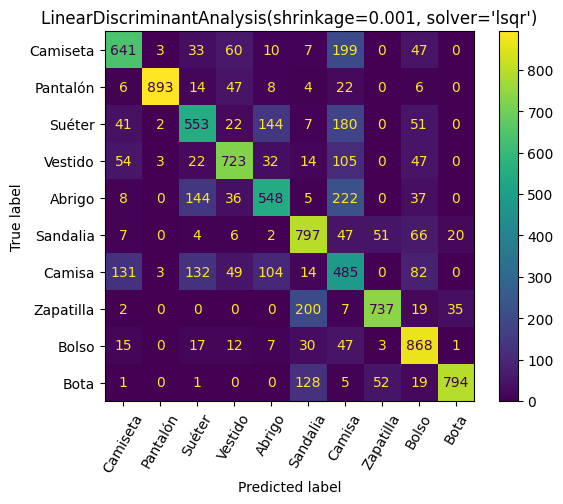

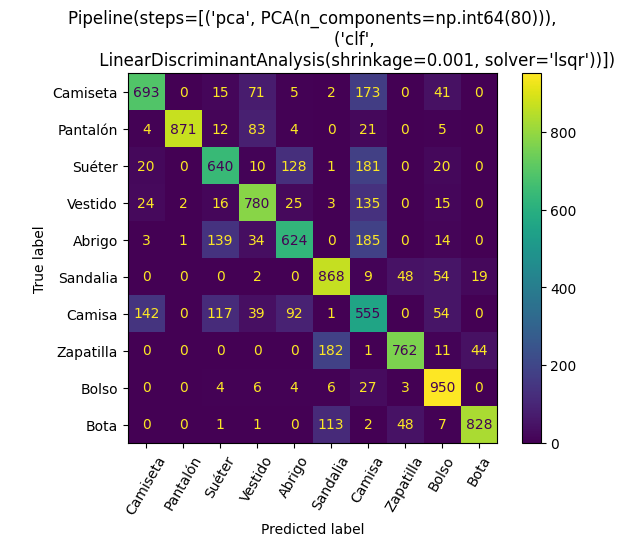

In [54]:
# TODO: tu código

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

print("Evaluación en imágenes de test ruidosas")
evaluar_clasificador(
    clone(clf),
    X_train,
    y_train,
    X_test_noisy,
    y_test,
    display_labels=list(target_names_esp.values()),
)

print(f"\nEvaluación en espacio PCA ({mejor_nc} componentes)")
pipeline_noisy_pca = Pipeline([
    ("pca", PCA(n_components=mejor_nc)),
    ("clf", clone(clf)),
])

evaluar_clasificador(
    pipeline_noisy_pca,
    X_train,
    y_train,
    X_test_noisy,
    y_test,
    display_labels=list(target_names_esp.values()),
)


## Conclusión.

En las matrices de confusión vemos que los resultados de ambos modelos son bastante parecidos, 
sin embargo, el uso de PCA mejora el modelo, reduce aumenta los valores de la diagonal, reduciendo algunas confusiones, especialmente la de Suéter, Vestido y Abrigo por Camisa.

Vemos el uso de todas las dimensiones parace hacer que el modelo inicial aprenda componentes que no son del todo relevantes y pueden hacer que se prediga de forma incorrecta alguna prenda en concreto como la Camisa.

### 2.3. Interpretación visual de PCA $\to$ Visualización 3D

Una forma intersante de interpretar el resultado de PCA es visualizar la localización <br>
de los datos (imágenes de Fashion-MNIST) según las 3 primeras componentes principales <br> 
$PC_1, PC_2, PC_3$.

En primer lugar, importamos algunas librerías adicionales necesarias para la visualización 3D:

In [5]:
import io

from PIL import Image

# en Google Colab?
try:
    import google.colab  # type:ignore

    IN_COLAB = True
    from IPython.display import HTML, display
except ImportError:
    IN_COLAB = False

# k3d instalado?:
try:
    import k3d
except ImportError as e:
    print("Instalando K3D-jupyter...")
    if IN_COLAB:
        %pip install k3d
        import k3d
    else:
        print(
            "Por favor, instala K3D-jupyter en tu entorno virtual. Por ejemplo (en conda), con:\n"
            "conda install k3d -c conda-forge"
        )
        raise e


Función para visualizar las imágenes en 3D:

In [6]:
def plot_pca_3d(X, n_images, random=False):
    """Función auxiliar para visualizar un subset de imágenes en 3D usando PCA."""
    assert len(X) >= n_images, f"Solo hay {len(X)} imágenes en el dataset."
    pca_3d = PCA(n_components=3)
    pca_3d.fit(X)
    idx = (
        np.random.choice(len(X), n_images, replace=False)
        if random
        else np.arange(n_images)
    )
    subset = X[idx]
    subset_pca = pca_3d.transform(subset)  # (ns, n_components)
    subset_gray = (255 * subset).astype(np.uint8).reshape(-1, 28, 28)
    # transform to PIL images for later conversion to binary
    subset_pil = [Image.fromarray(subset_gray[i], mode="L") for i in range(len(subset))]

    # initialize plot
    plot = k3d.factory.plot(
        grid_visible=False,
        camera_mode="trackball",
        camera_auto_fit=False,
    )

    # add images as textures
    for i, im in enumerate(subset_pil):
        image_bytes = io.BytesIO()
        image_format = "PNG"  # or 'JPEG'
        im.save(image_bytes, format=image_format)
        im_bytes = image_bytes.getvalue()
        plt_texture = k3d.texture(
            im_bytes, file_format="png", translation=subset_pca[i]
        )
        plot += plt_texture

    # add origin coordinate frame
    scale = np.abs(subset_pca).mean()
    plot += k3d.vectors(
        np.zeros((3, 3), dtype=np.float32),
        scale * np.eye(3, dtype=np.float32),
        # [R, R, G, G, B, B]
        colors=[0xFF0000, 0xFF0000, 0x00FF00, 0x00FF00, 0x0000FF, 0x0000FF],
        labels=["X", "Y", "Z"],
        line_width=5e-2,
        head_size=3.0,
    )

    # set camera position
    # fmt:off
    plot.camera = [
        0.0, 0.0, 5.0 * scale, # xyz
        0.0, 0.0, 0.0,
        0.0, -1.0, 0.0,
    ]
    # fmt:on
    if IN_COLAB:
        plot.snapshot_type = "inline"
        display(HTML(plot.get_snapshot()))
    else:
        plot.display()
    return plot

¿Qué determina la ubicación de las imágenes en 3D?

¿Qué efecto tiene PCA en la distribución de las imágenes de la siguiente visualización?

¿Se observa el mismo tipo de distribución si se emplean las imágenes ruidosas? ¿Por qué?

<div class="alert alert-block alert-info">
🛈 Al ejecutar por primera vez la siguiente celda, es posible que aparezca el Warning: <br>
<em>"Widgets require us to install supporting files from a 3rd party website"</em><br>
En ese caso Presiona "Ok"
</div>

In [7]:
plot = plot_pca_3d(X_train, 100, random=False)

c:\Users\eduar\AppData\Local\Programs\Python\Python313\Lib\site-packages\traittypes\traittypes.py:98: UserWarning: Given trait value dtype "float64" does not match required type "float32". A coerced copy has been created.
  warnings.warn(


Output()

## Preguntas.

**¿Qué determina la ubicación de las imágenes en 3D?**
La ubicación exacta de cada imagen en la visualización 3D está determinada por el valor de sus tres primeras componentes principales obtenidas tras aplicar la transformación PCA. Al proyectar los datos desde su alta dimensionalidad original hacia un nuevo subespacio reducido, el algoritmo calcula tres valores específicos para cada muestra. Estos tres valores numéricos actúan matemáticamente como las coordenadas espaciales ($X$, $Y$, $Z$) que indican la posición de traslación exacta donde se renderizará cada imagen dentro de de la gráfica tridimensiional.

**¿Qué efecto tiene PCA en la distribución de las imágenes de la siguiente visualización?**
Lo que hace el PCA es agrupar las imágenes según lo parecidas que sean. Como los primeros componentes se quedan con la información que más varía (es decir, los rasgos y formas que más destacan de la ropa), las prendas de la misma clase terminan teniendo resultados muy parecidos. Por eso, en el gráfico vemos que la ropa del mismo tipo se junta formando grupitos o clústeres, separándose un montón de las prendas que tienen formas totalmente distintas.

**¿Se observa el mismo tipo de distribución si se emplean las imágenes ruidosas? ¿Por qué?**
No, la verdad es que no sale igual. Al meterle ruido Gaussiano a las imágenes, le estamos añadiendo una variación artificial a los datos que estropea toda la proyección. Si el ruido es poco, los grupos se empiezan a esparcir y ya no se ven tan definidos. Pero si le metemos mucho ruido, esta variación aleatoria acaba tapando la forma real de la ropa. Entonces el PCA empieza a colocar las imágenes fijándose en el ruido y no en la prenda en sí, por lo que todo acaba colapsando en una sola nube mezclada donde es imposible distinguir qué tipo de ropa es cada cosa.